# Sneha Singh
## DATA 266 — Homework 5
Fine-tune flan-t5-small with LoRA on DialogSum


In [1]:
# libraries for this homework
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
from datasets import load_dataset
from peft import LoraConfig, TaskType, get_peft_model
from transformers import (
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
)

# last 4 of my SJSUid - 0670
SID4 = 670
SEED = SID4
SLICE = SID4 % 1000
HP_ID = SID4 % 6
CLS_A = SID4 % 10
CLS_B = (CLS_A + 1 + ((SID4 // 10) % 9)) % 10

# set seeds
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("SID4:", SID4)
print("SEED:", SEED)
print("SLICE:", SLICE)
print("HP_ID:", HP_ID)
print("CLS_A:", CLS_A)
print("CLS_B:", CLS_B)
print("device:", DEVICE)
print("HP_ID is reported only. no extra HP model this hw")
print("two trained models = LoRA r=4 and LoRA r=16")


/Users/snehasingh/Desktop/Gen-Ai/.venv-hw1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SID4: 670
SEED: 670
SLICE: 670
HP_ID: 4
CLS_A: 0
CLS_B: 5
device: mps
HP_ID is reported only. no extra HP model this hw
two trained models = LoRA r=4 and LoRA r=16


HW5 said follow the same step 0 as assignment 1. I did not copy the HW1 diabetes notebook. I only reused the standing parameters: SID4=670, SEED=670, SLICE=670, HP_ID=4, CLS_A=0, CLS_B=5, and I seeded python / numpy / torch with 670.

HW1 used HP_ID for a second network (15 vs 30 epochs). This assignment said skip that. The r=4 run and the r=16 run are the two trained models.


## 1. Data preparation

Dataset: `neil-code/dialogsum-test`.

Input is the dialogue. Target is the summary.


In [2]:
# load dialogsum
raw = load_dataset("neil-code/dialogsum-test")
print(raw)
print("columns:", raw["train"].column_names)


DatasetDict({
    train: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 1999
    })
    validation: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 499
    })
    test: Dataset({
        features: ['id', 'dialogue', 'summary', 'topic'],
        num_rows: 499
    })
})
columns: ['id', 'dialogue', 'summary', 'topic']


### 1.1 Two processed samples

Prefix so flan-t5 knows the task: `summarize the dialogue:`

Train subset is 256 rows, shuffled with SEED. The two dialogues I compare later are from validation, so they are not in that subset.


In [3]:
def prompt_of(dialogue):
    return "summarize the dialogue:\n" + dialogue

N_TRAIN = 256
demo = raw["validation"].shuffle(seed=SEED).select(range(2))
train_raw = raw["train"].shuffle(seed=SEED).select(range(N_TRAIN))

print("train rows:", len(train_raw))
print("held-out ids:", [demo[i]["id"] for i in range(2)])

for i in range(2):
    row = train_raw[i]
    print("\n===== sample", i + 1, "|", row["id"], "|", row["topic"], "=====")
    print("INPUT:")
    print(prompt_of(row["dialogue"]))
    print("TARGET:")
    print(row["summary"])

dialogues = [demo[i]["dialogue"] for i in range(2)]
references = [demo[i]["summary"] for i in range(2)]
demo_ids = [demo[i]["id"] for i in range(2)]


train rows: 256
held-out ids: ['dev_56', 'dev_357']

===== sample 1 | train_938 | Human Resource Department =====
INPUT:
summarize the dialogue:
#Person1#: What does Human Resources Department do?
#Person2#: Hiring, firing, training, insurances, benefits, retirement plans, salary, vacation.
#Person1#: They take care of a lot of things.
#Person2#: But most of time, they provide assistances.
#Person1#: What do you mean?
#Person2#: Say if the Engineering Department wants to hire a person, they will request HR to find candidates.
#Person1#: Yes?
#Person2#: The Engineering Manager and his team will interview the candidates. HR will also be involved with the interview, but basically arranging the schedule and explaining the benefits.
#Person1#: OK.
#Person2#: Then the Engineering Manager will choose the candidate.
#Person1#: I see.
TARGET:
#Person2# answers #Person1# the functions of the Human Resource Department and #Person2# tells #Person1# examples.

===== sample 2 | train_1943 | see an a

## 2. Baseline inference

`google/flan-t5-small`, no LoRA. Same two validation dialogues as section 5.


In [4]:
MODEL_NAME = "google/flan-t5-small"
MAX_INPUT = 256
MAX_TARGET = 64

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def generate_summary(model, dialogue):
    text = prompt_of(dialogue)
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_INPUT)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    model.eval()
    with torch.no_grad():
        ids = model.generate(
            **inputs, max_new_tokens=MAX_TARGET, num_beams=2, early_stopping=True
        )
    return tokenizer.decode(ids[0], skip_special_tokens=True)

base = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
n_total = sum(p.numel() for p in base.parameters())
print("baseline total params:", f"{n_total:,}")
print("baseline trainable params:", f"{n_total:,}")

baseline_outs = []
for i, dialogue in enumerate(dialogues):
    text = generate_summary(base, dialogue)
    baseline_outs.append(text)
    print("\n===== baseline", demo_ids[i], "=====")
    print("DIALOGUE:")
    print(dialogue)
    print("REFERENCE:")
    print(references[i])
    print("BASELINE:")
    print(text)

del base
if DEVICE == "mps":
    torch.mps.empty_cache()


Loading weights: 100%|█████████████████████| 190/190 [00:00<00:00, 4138.80it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


baseline total params: 76,961,152
baseline trainable params: 76,961,152

===== baseline dev_56 =====
DIALOGUE:
#Person1#: I don't understand why some parents keep beefing and complaining about their daughters not being able to follow suit.
#Person2#: Yeah. Li Na's mother has been building a fire under her since her neighbour's daughter got married with a Canadian. She's almost driving Li Na crazy.
#Person1#: If I were Li Na, I would ask her if she had done that.
#Person2#: She is as meek as a lamb. She never goes against anyone or anything. She's as good as gold, you know?
REFERENCE:
#Person1# and #Person2# talk about Li Na who is pressed by her mother for marriage.
BASELINE:
Li Na's mother has been building a fire under her since her neighbour's daughter got married.

===== baseline dev_357 =====
DIALOGUE:
#Person1#: Adam. I'm sorry.
#Person2#: Where have you been, Alice, you're over an hour late.
#Person1#: Yes, But I couldn't help it. I was late getting off work for a start and then

## 3. Apply LoRA

Freeze the pretrained weights. Train a small update ΔW = B × A (lecture 5).

- rank r = 4 and r = 16
- alpha = 16
- dropout = 0.05
- attach to `q` and `v`

Base model stays frozen. Only the adapter matrices are trainable.


In [5]:
LORA_ALPHA = 16
LORA_DROPOUT = 0.05

def attach_lora(rank):
    torch.manual_seed(SEED)
    base = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
    config = LoraConfig(
        r=rank,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        bias="none",
        task_type=TaskType.SEQ_2_SEQ_LM,
        target_modules=["q", "v"],
    )
    return get_peft_model(base, config)

def param_counts(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

# print counts, then drop the model. training is the next section.
for rank in (4, 16):
    model = attach_lora(rank)
    total, trainable = param_counts(model)
    print(f"\n===== LoRA r={rank} alpha={LORA_ALPHA} dropout={LORA_DROPOUT} =====")
    print("total parameters:", f"{total:,}")
    print("trainable parameters:", f"{trainable:,} ({100 * trainable / total:.3f}%)")
    model.print_trainable_parameters()
    del model


Loading weights: 100%|████████████████████| 190/190 [00:00<00:00, 11348.71it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.



===== LoRA r=4 alpha=16 dropout=0.05 =====
total parameters: 77,133,184
trainable parameters: 172,032 (0.223%)
trainable params: 172,032 || all params: 77,133,184 || trainable%: 0.2230


Loading weights: 100%|████████████████████| 190/190 [00:00<00:00, 10873.19it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.



===== LoRA r=16 alpha=16 dropout=0.05 =====
total parameters: 77,649,280
trainable parameters: 688,128 (0.886%)
trainable params: 688,128 || all params: 77,649,280 || trainable%: 0.8862


## 4. Fine-tuning

256 dialogues, 2 epochs, batch 4, lr `1e-3`. I train r=4 first, then r=16. Each one saves its adapter.


In [6]:
# tokenize the 256 training rows once
def tokenize(batch):
    model_inputs = tokenizer(
        [prompt_of(d) for d in batch["dialogue"]],
        max_length=MAX_INPUT,
        truncation=True,
        padding="max_length",
    )
    labels = tokenizer(
        text_target=batch["summary"],
        max_length=MAX_TARGET,
        truncation=True,
        padding="max_length",
    )
    model_inputs["labels"] = [
        [(tok if tok != tokenizer.pad_token_id else -100) for tok in seq]
        for seq in labels["input_ids"]
    ]
    return model_inputs

train_tok = train_raw.map(tokenize, batched=True, remove_columns=train_raw.column_names)
collator = DataCollatorForSeq2Seq(tokenizer=tokenizer, model=MODEL_NAME)

EPOCHS = 2
BATCH = 4
LR = 1e-3
Path("adapters").mkdir(exist_ok=True)

runs = {}
for rank in (4, 16):
    print("\n===== train r =", rank, "=====")
    model = attach_lora(rank)
    args = TrainingArguments(
        output_dir=f"outputs/trainer_r{rank}",
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH,
        learning_rate=LR,
        logging_steps=8,
        save_strategy="no",
        report_to="none",
        seed=SEED,
        dataloader_pin_memory=False,
        remove_unused_columns=False,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        data_collator=collator,
    )
    result = trainer.train()
    history = [h for h in trainer.state.log_history if "loss" in h]
    print(f"final training loss (r={rank}): {result.training_loss:.4f}")
    print("last logged loss:", round(history[-1]["loss"], 4))
    model.save_pretrained(f"adapters/r{rank}")
    print("saved adapters/r" + str(rank))
    runs[rank] = {
        "model": model.to(DEVICE),
        "final_loss": float(result.training_loss),
        "history": history,
    }
    if DEVICE == "mps":
        torch.mps.empty_cache()


Map: 100%|██████████████████████████| 256/256 [00:00<00:00, 2742.93 examples/s]



===== train r = 4 =====


Loading weights: 100%|█████████████████████| 190/190 [00:00<00:00, 9150.93it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Step,Training Loss
8,2.464466
16,1.954447
24,1.924367
32,1.853283
40,1.700919
48,1.728913
56,1.770110
64,1.822980
72,2.024007
80,1.629295


final training loss (r=4): 1.7963
last logged loss: 1.5108
saved adapters/r4

===== train r = 16 =====


Loading weights: 100%|█████████████████████| 190/190 [00:00<00:00, 3272.76it/s]
[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Step,Training Loss
8,2.458608
16,1.952236
24,1.928705
32,1.843423
40,1.699852
48,1.726924
56,1.769068
64,1.822838
72,2.014743
80,1.631907


final training loss (r=16): 1.7933
last logged loss: 1.4983
saved adapters/r16


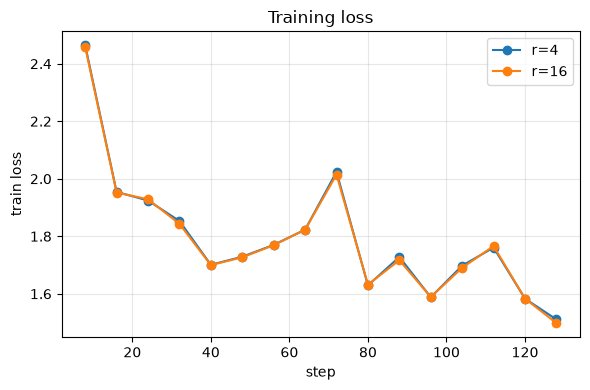

In [7]:
# loss curve
plt.figure(figsize=(6, 4))
for rank, run in runs.items():
    plt.plot(
        [h["step"] for h in run["history"]],
        [h["loss"] for h in run["history"]],
        marker="o",
        label=f"r={rank}",
    )
plt.xlabel("step")
plt.ylabel("train loss")
plt.title("Training loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
plt.savefig("figures/train_loss.png", dpi=140)
plt.show()


## 5. After fine-tuning

Same two dialogues as the baseline (`demo_ids` from section 1).


In [8]:
after = {}
for rank, run in runs.items():
    preds = []
    print("\n===== after r =", rank, "=====")
    for i, dialogue in enumerate(dialogues):
        text = generate_summary(run["model"], dialogue)
        preds.append(text)
        print(f"\n--- {demo_ids[i]} ---")
        print(text)
    after[rank] = preds



===== after r = 4 =====

--- dev_56 ---
Li Na's mother has been building a fire under her neighbour's daughter.

--- dev_357 ---
Alice's late getting off work for a start and then she misses the bus. Alice's boss asks Alice to do urgent letters.

===== after r = 16 =====

--- dev_56 ---
Li Na's mother has been building a fire under Li Na's neighbour's daughter.

--- dev_357 ---
Adam is over an hour late. Alice is late getting off work for a start and then misses the bus. #Person1#'s boss asks Alice to do urgent letters.


## 6. Before vs after


In [9]:
for i in range(2):
    print("===== dialogue", i + 1, "|", demo_ids[i], "=====")
    print("REFERENCE:", references[i])
    print("BEFORE:   ", baseline_outs[i])
    print("AFTER r=4:", after[4][i])
    print("AFTER r=16:", after[16][i])
    print()


===== dialogue 1 | dev_56 =====
REFERENCE: #Person1# and #Person2# talk about Li Na who is pressed by her mother for marriage.
BEFORE:    Li Na's mother has been building a fire under her since her neighbour's daughter got married.
AFTER r=4: Li Na's mother has been building a fire under her neighbour's daughter.
AFTER r=16: Li Na's mother has been building a fire under Li Na's neighbour's daughter.

===== dialogue 2 | dev_357 =====
REFERENCE: Alice is over an hour late for the appointment with Adam. She explains the reason for her lateness and apologizes.
BEFORE:    Adam, I'm sorry. I'm sorry.
AFTER r=4: Alice's late getting off work for a start and then she misses the bus. Alice's boss asks Alice to do urgent letters.
AFTER r=16: Adam is over an hour late. Alice is late getting off work for a start and then misses the bus. #Person1#'s boss asks Alice to do urgent letters.



Before fine-tuning, dialogue 1 is just a copied line ("building a fire under her...") and dialogue 2 is only "I'm sorry."

After LoRA, both ranks try to pack several facts into a short summary. On the late-for-the-appointment dialogue they mention leaving work late, missing the bus, and the urgent letters, which the baseline never got to. Rank 16 writes a longer second summary, but it says Adam is late when Alice is the one who is late.


## 7. Rank experiment (r=4 vs r=16)

Same alpha (16) and dropout (0.05). r=16 has more trainable weights. I compare loss and a simple unigram overlap with the reference summary.


In [10]:
# unigram F1, just to put a number next to the two summaries
from collections import Counter

def rouge1_f1(pred, ref):
    p = pred.lower().split()
    r = ref.lower().split()
    if not p or not r:
        return 0.0
    overlap = sum((Counter(p) & Counter(r)).values())
    prec = overlap / len(p)
    rec = overlap / len(r)
    if prec + rec == 0:
        return 0.0
    return 2 * prec * rec / (prec + rec)

print("baseline mean rouge1:", round(sum(rouge1_f1(p, r) for p, r in zip(baseline_outs, references)) / 2, 3))
for rank in (4, 16):
    scores = [rouge1_f1(p, r) for p, r in zip(after[rank], references)]
    print(
        f"r={rank}  loss={runs[rank]['final_loss']:.4f}  "
        f"rouge1={scores[0]:.3f}, {scores[1]:.3f}  mean={sum(scores)/2:.3f}"
    )


baseline mean rouge1: 0.097
r=4  loss=1.7963  rouge1=0.222, 0.286  mean=0.254
r=16  loss=1.7933  rouge1=0.143, 0.375  mean=0.259


r=16 trains about 4× as many adapter weights as r=4, but the two loss curves sit on top of each other (both end near 1.50, mean train loss about 1.79).

On these two dialogues the mean overlap is almost the same. r=16 is a bit closer on the Alice dialogue and worse on the Li Na one, and it swaps who is late. With 256 examples and 2 epochs, the higher rank does not give a clearly better summary. A small rank is enough for this run.
